In [9]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [13]:
data = pd.read_csv("data\diabetesdata.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [14]:
data = data.drop([
    'Pregnancies',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'DiabetesPedigreeFunction',
    'Age'
], axis=1)

In [15]:
import numpy as np 
print(data.head())
print(data.columns)
data_np = data.to_numpy()
data_np

   Glucose   BMI  Outcome
0      148  33.6        1
1       85  26.6        0
2      183  23.3        1
3       89  28.1        0
4      137  43.1        1
Index(['Glucose', 'BMI', 'Outcome'], dtype='object')


array([[148. ,  33.6,   1. ],
       [ 85. ,  26.6,   0. ],
       [183. ,  23.3,   1. ],
       ...,
       [121. ,  26.2,   0. ],
       [126. ,  30.1,   1. ],
       [ 93. ,  30.4,   0. ]])

In [16]:
X= data_np[:, [0, 1]]
X

array([[148. ,  33.6],
       [ 85. ,  26.6],
       [183. ,  23.3],
       ...,
       [121. ,  26.2],
       [126. ,  30.1],
       [ 93. ,  30.4]])

In [17]:
y = data_np[:, -1]
y = y.reshape(-1, 1)
y

array([[1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],

In [18]:
X

array([[148. ,  33.6],
       [ 85. ,  26.6],
       [183. ,  23.3],
       ...,
       [121. ,  26.2],
       [126. ,  30.1],
       [ 93. ,  30.4]])

In [19]:
y.shape

(768, 1)

In [20]:
m = y.size
X_ext = np.c_[np.ones(m), X]


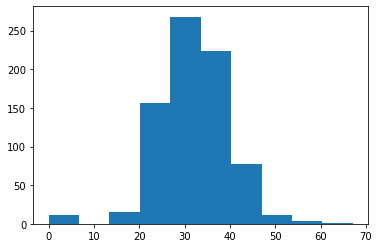

In [21]:
plt.hist(data['BMI'])
plt.show()

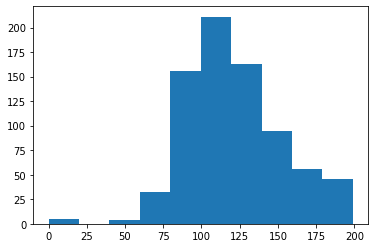

In [22]:
plt.hist(data['Glucose'])
plt.show()

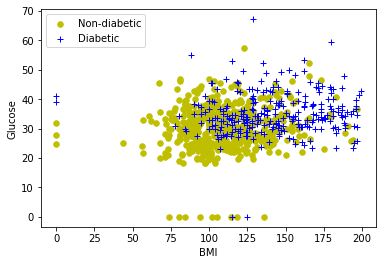

In [23]:
# plot
ind0 = np.nonzero(y == 0)[0]
ind1 = np.nonzero(y == 1)[0]

plt.scatter(X[ind0,0], X[ind0,1], s=30, c='y', marker='o', linewidths=1, label='Non-diabetic')
plt.scatter(X[ind1,0], X[ind1,1], s=30, c='b', marker='+', linewidths=1, label='Diabetic')

plt.xlabel('BMI')       
plt.ylabel('Glucose')    

plt.legend()
plt.show()

In [24]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [26]:
def sigmoid(z):
    
    sig = 1/(1+np.exp(-z))
    
    return sig

In [27]:
def costFunction(X, y, theta=[[0], [0], [0]]):
    m = y.size
    X_extend = np.c_[np.ones(m), X]
    z = X_extend.dot(theta)
    h = sigmoid(z)
    cost = -1/(m)*np.sum(y*np.log(h)+(1-y)*np.log(1-h))
    
    return cost

In [28]:

costFunction( X, y )

0.6931471805599452

In [29]:
 def gradientDescent(X, y, theta=[[0], [0], [0]], epochs = 5000, learning_rate = 0.001):
    
    m = y.size
    X_extend = np.c_[np.ones(m), X]
    j_history = np.zeros(epochs)

    n_print = epochs//10

    for i in range(epochs):
        
        z = X_extend.dot(theta)
        h = sigmoid(z)
        epsilon = 1e-15 
        h = np.clip(h, epsilon, 1 - epsilon)
        
        
        theta[0] = theta[0]-(learning_rate/m)*np.sum(h-y)
        theta[1] = theta[1]-(learning_rate/m)*np.sum((h-y)*X[:,0:1])
        theta[2] = theta[2]-(learning_rate/m)*np.sum((h-y)*X[:,1:2])

        j = -1/m*np.sum(y*np.log(h)+(1-y)*np.log(1-h))
        j_history[i] = j 
        
        if (i+1) % n_print == 0:
            print("Iteration", i+1, " | Cost: ", j, "\n")
    
    return  theta, j_history

In [35]:
theta , j_history = gradientDescent( X , y, epochs=250000)

Iteration 25000  | Cost:  1.1659816318832226 

Iteration 50000  | Cost:  1.1155896746721334 

Iteration 75000  | Cost:  1.069656474022143 

Iteration 100000  | Cost:  1.028273957164654 

Iteration 125000  | Cost:  0.9914298055404454 

Iteration 150000  | Cost:  0.9589900670247468 

Iteration 175000  | Cost:  0.9307105263234787 

Iteration 200000  | Cost:  0.9062654767280351 

Iteration 225000  | Cost:  0.8852810038817323 

Iteration 250000  | Cost:  0.8673659703938308 



In [36]:
theta

[array([-11.58556058]), array([0.07819922]), array([0.10270269])]

Text(0, 0.5, 'Cost value')

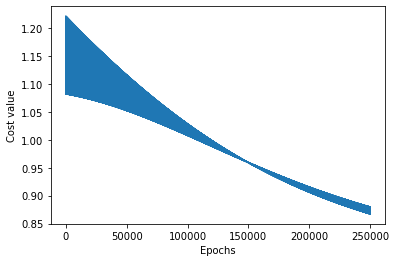

In [37]:
plt.plot(j_history)
plt.xlabel('Epochs')
plt.ylabel('Cost value')

In [38]:
pos = (y == 1).ravel()
neg = (y == 0).ravel()

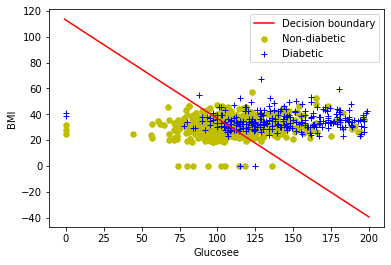

In [40]:
import numpy as np
import matplotlib.pyplot as plt


ind0 = np.nonzero(y == 0)[0]  
ind1 = np.nonzero(y == 1)[0]  


plt.scatter(X[ind0,0], X[ind0,1], s=30, c='y', marker='o', linewidths=1, label='Non-diabetic')
plt.scatter(X[ind1,0], X[ind1,1], s=30, c='b', marker='+', linewidths=1, label='Diabetic')


x_plot = np.array([X[:,0].min()-1, X[:,0].max()+1])  
y_plot = -(theta[0] + theta[1]*x_plot) / theta[2] 


plt.plot(x_plot, y_plot, 'r-', label='Decision boundary')


plt.xlabel('Glucosee')
plt.ylabel('BMI')
plt.legend()
plt.show()

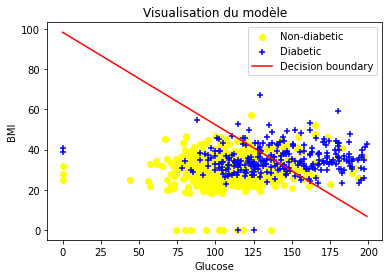

In [45]:
import matplotlib.pyplot as plt
import numpy as np


plt.scatter(X[y==0]['Glucose'], X[y==0]['BMI'], color='yellow',marker='o', label='Non-diabetic')
plt.scatter(X[y==1]['Glucose'], X[y==1]['BMI'], color='blue',marker='+', label='Diabetic')


theta0 = model.intercept_[0]
theta1, theta2 = model.coef_[0]

x_vals = np.linspace(X['Glucose'].min(), X['Glucose'].max(), 100)
y_vals = -(theta0 + theta1 * x_vals) / theta2


plt.plot(x_vals, y_vals, 'r-', label='Decision boundary')


plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.legend()
plt.title("Visualisation du modèle")
plt.show()

In [43]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

data = pd.read_csv("data/diabetesdata.csv")

X = data[['Glucose', 'BMI']]
y = data['Outcome']

model = LogisticRegression()

model.fit(X, y)


predictions = model.predict(X)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

print("\nFirst 10 predictions:")
print(predictions[:10])

Coefficients: [[0.03516872 0.0763209 ]]
Intercept: [-7.51516287]

First 10 predictions:
[1 0 1 0 1 0 0 0 1 0]
